In [1]:
%%capture
%pip install -e lambda/virtualizarr-processor

In [3]:
import icechunk
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from virtualizarr_processor.helpers import open_or_create_repo

storage = icechunk.s3_storage(
    bucket='nasa-eodc-public',
    prefix='icechunk/gpmimerg_hh_07',
    region='us-west-2',
    anonymous=True,
)

In [4]:
repo = open_or_create_repo(storage=storage)

session = repo.readonly_session('main')
ds = xr.open_zarr(session.store, consolidated=False, zarr_version=3, chunks={})
ds

/tmp/ipykernel_258/2724810221.py:4: FutureWarning: zarr_version is deprecated, use zarr_format
  ds = xr.open_zarr(session.store, consolidated=False, zarr_version=3, chunks={})
/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 50TB
Dimensions:                         (time: 486480, lon: 3600, lat: 1800)
Coordinates:
  * time                            (time) datetime64[ns] 4MB 1998-01-01 ... ...
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
Data variables:
    precipitation                   (time, lon, lat) float32 13TB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    precipitationQualityIndex       (time, lon, lat) float32 13TB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 13TB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    probabilityLiquidPrecipitation  (time, lon, lat) float32 13TB dask.array<chunksize=(1, 291, 1800), meta=np.ndarray>
Attributes:
    GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeRe...

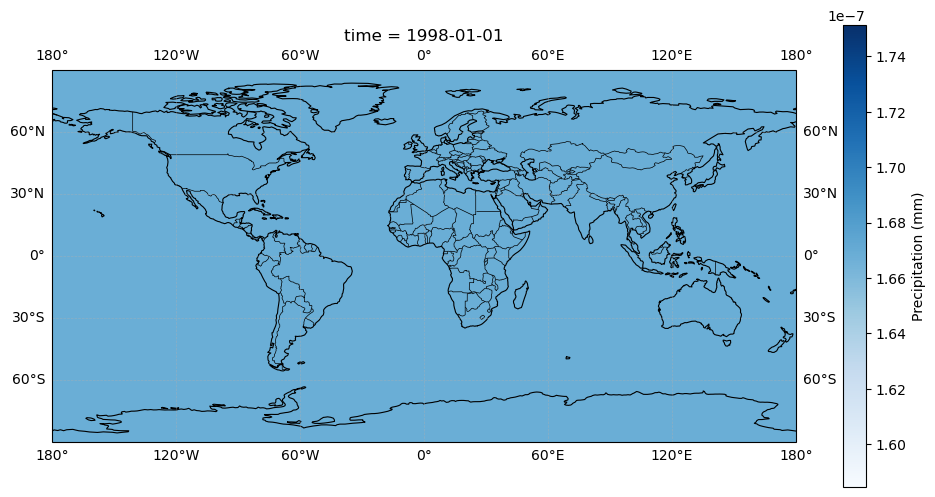

In [6]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

data = ds.precipitation[0,:,:].transpose('lat', 'lon')

vmin = float(data.quantile(0.05))
vmax = float(data.quantile(0.95))

data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Precipitation (mm)'}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)  # land background
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=0) # ocean background
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)

plt.show()